In [1]:

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split,RandomizedSearchCV,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report,RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

df=pd.read_csv("../../data/final/heart_final.csv")
X=df.drop("cardio",axis=1)
y=df["cardio"]

X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.2,stratify=y,random_state=42)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [2]:

models={
"Logistic Regression":LogisticRegression(max_iter=1000),
"Decision Tree":DecisionTreeClassifier(random_state=42),
"Random Forest":RandomForestClassifier(random_state=42),
"SVM":SVC(probability=True),
"KNN":KNeighborsClassifier(),
"Naive Bayes":GaussianNB(),
"XGBoost":XGBClassifier(eval_metric="logloss",random_state=42),
"LightGBM":LGBMClassifier(random_state=42,verbosity=-1),
"CatBoost":CatBoostClassifier(verbose=0,random_state=42)
}

results=[]

for n,m in models.items():
    if n in ["Logistic Regression","SVM","KNN","Naive Bayes"]:
        m.fit(X_train_scaled,y_train)
        pred=m.predict(X_test_scaled)
        proba=m.predict_proba(X_test_scaled)[:,1]
    else:
        m.fit(X_train,y_train)
        pred=m.predict(X_test)
        proba=m.predict_proba(X_test)[:,1]

    results.append([n,
                    accuracy_score(y_test,pred),
                    precision_score(y_test,pred),
                    recall_score(y_test,pred),
                    f1_score(y_test,pred),
                    roc_auc_score(y_test,proba)])

results=pd.DataFrame(results,columns=["Model","Accuracy","Precision","Recall","F1","ROC_AUC"])
results=results.sort_values("Accuracy",ascending=False)
display(results)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
7,LightGBM,0.737181,0.760570,0.710192,0.734518,0.803130
8,CatBoost,0.735759,0.758961,0.709022,0.733142,0.801724
6,XGBoost,0.730444,0.754800,0.701272,0.727052,0.798327
3,SVM,0.730070,0.745856,0.717064,0.731176,0.790663
0,Logistic Regression,0.718093,0.736203,0.700249,0.717776,0.785250
2,Random Forest,0.702223,0.709843,0.707560,0.708699,0.749952
4,KNN,0.659031,0.671936,0.652581,0.662117,0.703661
1,Decision Tree,0.612097,0.623197,0.612809,0.617959,0.611363
5,Naive Bayes,0.607905,0.691828,0.422138,0.524337,0.685297


In [3]:

param_dist={
"n_estimators":[100,200,300],
"max_depth":[5,10,20,None],
"min_samples_split":[2,5,10],
"min_samples_leaf":[1,2,4]
}

search=RandomizedSearchCV(
RandomForestClassifier(random_state=42),
param_dist,
cv=5,
n_iter=20,
n_jobs=-1,
random_state=42)

search.fit(X_train,y_train)

best_model=search.best_estimator_
pred=best_model.predict(X_test)
proba=best_model.predict_proba(X_test)[:,1]

print(search.best_params_)
print("Accuracy:",accuracy_score(y_test,pred))


{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}
Accuracy: 0.7354592409611498


Classification Report
              precision    recall  f1-score   support

           0       0.71      0.78      0.74      6520
           1       0.77      0.69      0.73      6839

    accuracy                           0.74     13359
   macro avg       0.74      0.74      0.74     13359
weighted avg       0.74      0.74      0.74     13359



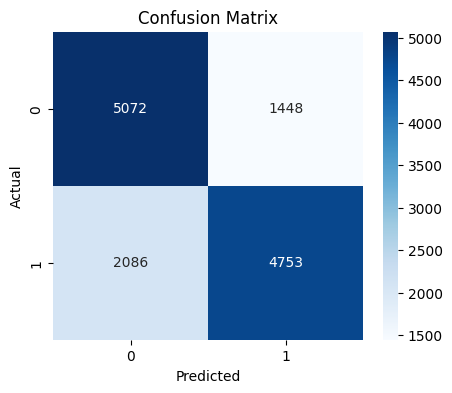

In [4]:

print("Classification Report")
print(classification_report(y_test,pred))

cm=confusion_matrix(y_test,pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


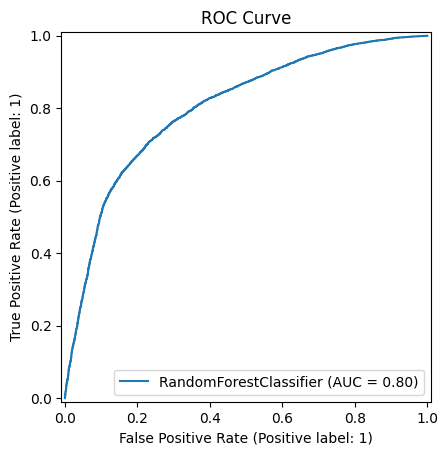

In [5]:

RocCurveDisplay.from_estimator(best_model,X_test,y_test)
plt.title("ROC Curve")
plt.show()


In [6]:

cv_score=cross_val_score(best_model,X,y,cv=5,scoring="accuracy")

print("Cross Validation Scores:",cv_score)
print("Mean Accuracy:",cv_score.mean())


Cross Validation Scores: [0.73014447 0.7368815  0.73394221 0.73266956 0.7277287 ]
Mean Accuracy: 0.7322732890256776


In [8]:

joblib.dump(best_model,"../../models/best_model_heart.pkl")
joblib.dump(scaler,"../../models/scaler_heart.pkl")
print("Model and scaler saved.")


Model and scaler saved.
